In [1]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

In [2]:
df_train = pd.read_csv(f"data-01-processed/ridge_regression_train.csv", index_col=[0])

df_train

,temp,atemp,hum,wind,temp_sq,hum_sq,wind_sq,temp_x_hum,temp_x_wind,atemp_x_hum,...,dayofyear,sin_doy_1,cos_doy_1,sin_doy_2,cos_doy_2,sin_doy_3,cos_doy_3,wcond_2,wcond_3,count
1,9.1,13.2,79.78,10.43,82.81,6364.8484,108.7849,725.998,94.913,1053.096,...,1,1.721336e-02,0.999852,3.442161e-02,0.999407,5.161967e-02,0.998667,True,False,982
2,9.9,12.7,68.91,16.16,98.01,4748.5881,261.1456,682.209,159.984,875.157,...,2,3.442161e-02,0.999407,6.880243e-02,0.997630,1.031017e-01,0.994671,True,False,797
3,3.1,4.5,43.29,16.14,9.61,1874.0241,260.4996,134.199,50.034,194.805,...,3,5.161967e-02,0.998667,1.031017e-01,0.994671,1.543088e-01,0.988023,False,False,1351
4,3.2,5.6,58.45,10.42,10.24,3416.4025,108.5764,187.040,33.344,327.320,...,4,6.880243e-02,0.997630,1.372788e-01,0.990532,2.051045e-01,0.978740,False,False,1559
5,4.3,6.5,43.26,12.15,18.49,1871.4276,147.6225,186.018,52.245,281.190,...,5,8.596480e-02,0.996298,1.712931e-01,0.985220,2.553533e-01,0.966848,False,False,1597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,8.3,11.4,75.49,12.25,68.89,5698.7401,150.0625,626.567,101.675,860.586,...,361,-6.880243e-02,0.997630,-1.372788e-01,0.990532,-2.051045e-01,0.978740,True,False,1161
362,7.3,9.0,49.89,19.11,53.29,2489.0121,365.1921,364.197,139.503,449.010,...,362,-5.161967e-02,0.998667,-1.031017e-01,0.994671,-1.543088e-01,0.988023,False,False,2301
363,5.2,8.2,56.84,7.76,27.04,3230.7856,60.2176,295.568,40.352,466.088,...,363,-3.442161e-02,0.999407,-6.880243e-02,0.997630,-1.031017e-01,0.994671,False,False,2421
364,7.8,10.9,63.03,8.73,60.84,3972.7809,76.2129,491.634,68.094,687.027,...,364,-1.721336e-02,0.999852,-3.442161e-02,0.999407,-5.161967e-02,0.998667,False,False,2995


# Cross Validation

In [3]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from scripts.find_alpha_ridge import cross_validate_ridge

In [ ]:
X = df_train[[col for col in df_train.columns if col != "count"]].to_numpy()

y = df_train["count"].to_numpy()

alphas = np.logspace(-4, np.log10(2), 1_000)

kf = KFold(n_splits=20, shuffle=True, random_state=RANDOM_STATE)

In [5]:
alphas

array([1.00000000e-04, 1.00099094e-04, 1.00198286e-04, ...,
       1.99604213e+00, 1.99802009e+00, 2.00000000e+00], shape=(10000,))

In [6]:
results = cross_validate_ridge(
    X = X,
    y = y,
    alphas=alphas,
    kf = kf
)

[Fold]: 0
[Fold]: 1
[Fold]: 2
[Fold]: 3
[Fold]: 4
[Fold]: 5
[Fold]: 6
[Fold]: 7
[Fold]: 8
[Fold]: 9
[Fold]: 10
[Fold]: 11
[Fold]: 12
[Fold]: 13
[Fold]: 14
[Fold]: 15
[Fold]: 16
[Fold]: 17
[Fold]: 18
[Fold]: 19


In [11]:
print(f"Best lambda : {results['best_alpha']:.4f}")
print(f"Best CV MSE : {results['best_cv_mse']:.2f}")
print(f"Best CV RMSE: {results['best_cv_rmse']:.2f}")

Best lambda : 0.0041
Best CV MSE : 294802.85
Best CV RMSE: 542.96


# Visualizing MSEs

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def plot_error(alphas: np.ndarray, cv_error: np.ndarray, sel_point_idx: int|None = None) -> None:
    plt.scatter(alphas, cv_error, s = 1, marker = ".")
    plt.xlabel("alpha")
    plt.ylabel("cv_rmse")

    if sel_point_idx is not None:
        plt.axvline(alphas[sel_point_idx], color = "red", ls = "--", lw = 0.5)

    plt.grid(True, ls = "--")

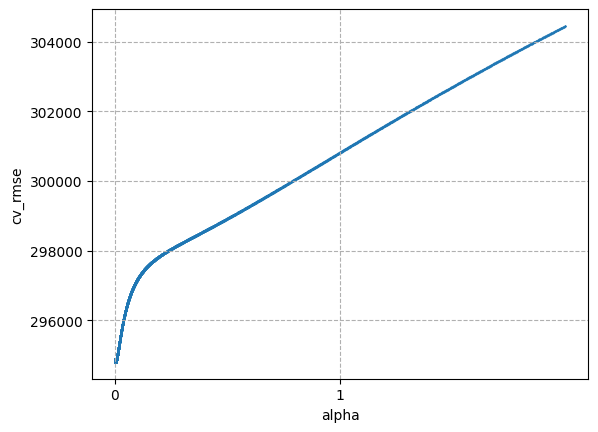

In [14]:
plot_error(alphas, results["cv_mse"])

# Szukanie Przegięcia

In [83]:
from scipy.signal import savgol_filter, find_peaks

In [97]:
def find_max_curvature_in_range(x: np.ndarray, y: np.ndarray,
                                 x_min: float = -np.inf,
                                 x_max: float = np.inf) -> int:
    """
    Find the index of maximum curvature within a specified x-range.

    :param x: 1-D array of x-coordinates (must be sorted).
    :param y: 1-D array of y-values corresponding to x.
    :param x_min: Lower bound of the search range (inclusive).
    :param x_max: Upper bound of the search range (inclusive).
    :return: Index in the original array of the point with maximum curvature.
    """
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)
    curvature = np.abs(d2y) / (1 + dy**2) ** 1.5

    mask = (x >= x_min) & (x <= x_max)
    local_idx = int(np.argmax(curvature[mask]))
    return int(np.where(mask)[0][local_idx])

def find_inflection_points(x: np.ndarray, y: np.ndarray, threshold: float = 0.0) -> np.ndarray:
    """
    Find inflection points of a discrete function by sign changes in the second derivative.

    :param x: 1-D array of x-coordinates (must be sorted).
    :param y: 1-D array of y-values corresponding to x.
    :param threshold: Minimum absolute value of d2y to consider a sign change significant.
    :return: Array of indices where inflection points are detected.
    """
    d2y = np.gradient(np.gradient(y, x), x)
    sign_changes = np.where(np.diff(np.sign(d2y)))[0]
    mask = np.abs(d2y[sign_changes]) > threshold
    return sign_changes[mask]

def find_elbow_points(x: np.ndarray, y: np.ndarray,
                      window: int = 10, poly: int = 2,
                      prominence: float = 0.05,
                      min_distance: int = 1) -> np.ndarray:
    """
    Find indices of multiple elbow points as local maxima of curvature.

    :param x: 1-D array of x-coordinates (must be sorted, uniformly spaced).
    :param y: 1-D array of y-values corresponding to x.
    :param window: Window length for Savitzky-Golay filter (odd integer >= poly + 2).
    :param poly: Polynomial order for Savitzky-Golay filter.
    :param prominence: Minimum prominence of a curvature peak relative to max curvature.
    :param min_distance: Minimum number of samples between detected elbows.
    :return: Array of indices where elbow points are detected, sorted by curvature descending.
    """
    delta = x[1] - x[0]
    dy = savgol_filter(y, window_length=window, polyorder=poly, deriv=1, delta=delta)
    d2y = savgol_filter(y, window_length=window, polyorder=poly, deriv=2, delta=delta)
    curvature = np.abs(d2y) / (1 + dy**2) ** 1.5

    abs_prominence = prominence * curvature.max()
    peaks, _ = find_peaks(curvature, prominence=abs_prominence, distance=min_distance)

    return peaks[np.argsort(curvature[peaks])[::-1]]

In [98]:
inflection_idxs = find_inflection_points(alphas, results["cv_mse"])

for alph_idx, alpha in zip(inflection_idxs, alphas[inflection_idxs]):
    print(f"[{alph_idx}\t]:\t\t{alpha:.3f}")

[5297	]:		0.019
[8257	]:		0.356
[9225	]:		0.929


In [99]:
max_curv_idxs = find_elbow_points(alphas, results["cv_mse"])

for alph_idx, alpha in zip(max_curv_idxs, alphas[max_curv_idxs]):
    print(f"[{alph_idx}\t]:\t\t{alpha:.3f}")

[3744	]:		0.004


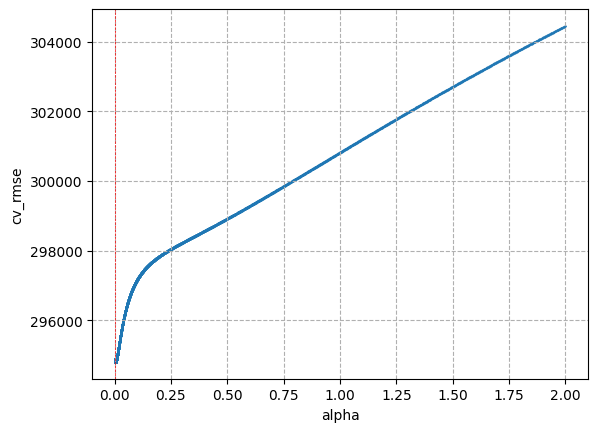

In [96]:
plot_error(
    alphas, results["cv_mse"], max_curv_idxs[0]
)

In [70]:
selected_alpha_idx = 8538

In [109]:
best_alpha = results["alphas"][selected_alpha_idx]

best_alpha = 10.0

# Fitting Best Model

In [110]:
from scripts.find_alpha_ridge import fit_final_ridge

In [111]:
model, scaler = fit_final_ridge(X, y, alpha=best_alpha)

In [112]:
df_test = pd.read_csv(f"data-01-processed/ridge_regression_test.csv", index_col=[0])

df_test_with_date = pd.read_csv(f"data-00-raw/bike_test.csv", index_col=[0])

In [113]:
preds = model.predict(scaler.transform(df_test.to_numpy()))

# Submission Generator

In [114]:
from scripts.save_submission import save_submission_csv

In [115]:
df_submission = pd.DataFrame({"date": df_test_with_date["date"], "pred": preds})

df_submission

,date,pred
1,2023-01-01,1914.222182
2,2023-01-02,1657.773510
3,2023-01-03,975.106110
4,2023-01-04,1175.209863
5,2023-01-05,1981.162359
...,...,...
361,2023-12-27,468.889351
362,2023-12-28,1794.392324
363,2023-12-29,2420.534677
364,2023-12-30,2175.173474


In [116]:
save_submission_csv(df_submission)